In [1]:
!pip install pandas

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   - -----------------------------

In [2]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.5 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.5 MB 3.4 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.5 MB 2.2 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.5 MB 2.3 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.5 MB 2.4 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 2.5 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.5 MB 2.5 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.5 MB 2.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.5 MB 2.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 2.4 MB/s eta 0:00:02
   ----------------

In [3]:
pip install yfinance numpy 

  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/137.8 kB ? eta -:--:--
   ---------------------------------------- 0.0/137.8 kB ? eta -:--:--
   -------- ------------------------------ 30.7/137.8 kB 660.6 kB/s eta 0:00:01
   ----------------- ---------------------- 61.4/137.8 kB 1.1 MB/s eta 0:00:01
   --------------------------------- ---- 122.9/137.8 kB 901.1 kB/s eta 0:00:01
   -------------------------------------- 137.8/137.8 kB 910.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.7 MB 1.7 MB/s eta 0:00:01
   - -------------------------------------- 0.1/1.7 MB 787.7 kB/s eta 0:00:03
   ----- ---------------------------------- 0.2/1.7 MB 1.7 MB/s eta 0:00:01
   -------- ------------------------------- 0.4/1.7 MB 2.0 MB/s eta 0:00:01
   ----------- ---------------------------- 0.5/1.7 MB 2.1 MB/s eta 0:00:01
   ------------- ---------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download NIFTY 50 data — 5 years
df = yf.download("^NSEI", start="2019-01-01", end="2024-01-01", auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df[["Close"]].dropna()

print(df.tail())

[*********************100%***********************]  1 of 1 completed

Price              Close
Date                    
2023-12-22  21349.400391
2023-12-26  21441.349609
2023-12-27  21654.750000
2023-12-28  21778.699219
2023-12-29  21731.400391


In [8]:
# Moving averages
df["SMA_50"]  = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

# Signal: 1 = long (buy), 0 = out of market
df["Signal"] = 0
df.loc[df["SMA_50"] > df["SMA_200"], "Signal"] = 1
df["Signal"] = df["Signal"].shift(1)  # avoid look-ahead bias

# Daily returns
df["Market_Return"]   = df["Close"].pct_change()
df["Strategy_Return"] = df["Market_Return"] * df["Signal"]

df.dropna(inplace=True)

In [9]:
# Cumulative returns
df["Cumulative_Market"]   = (1 + df["Market_Return"]).cumprod()
df["Cumulative_Strategy"] = (1 + df["Strategy_Return"]).cumprod()

# Sharpe Ratio (annualised, assuming 252 trading days)
sharpe = (df["Strategy_Return"].mean() / df["Strategy_Return"].std()) * np.sqrt(252)

# Max Drawdown
rolling_max = df["Cumulative_Strategy"].cummax()
drawdown    = (df["Cumulative_Strategy"] - rolling_max) / rolling_max
max_drawdown = drawdown.min()

# Annualised Return
total_days     = len(df)
annual_return  = (df["Cumulative_Strategy"].iloc[-1]) ** (252 / total_days) - 1

print(f"Sharpe Ratio      : {sharpe:.2f}")
print(f"Max Drawdown      : {max_drawdown:.2%}")
print(f"Annualised Return : {annual_return:.2%}")

Sharpe Ratio      : 0.40
Max Drawdown      : -36.48%
Annualised Return : 4.90%


In [10]:
market_annual_return = (df["Cumulative_Market"].iloc[-1]) ** (252 / total_days) - 1

print(f"Market Annualised Return : {market_annual_return:.2%}")

Market Annualised Return : 15.96%


In [14]:
buy = df[(df["Signal"] == 1) & (df["Signal"].shift(1) == 0)]
sell = df[(df["Signal"] == 0) & (df["Signal"].shift(1) == 1)]

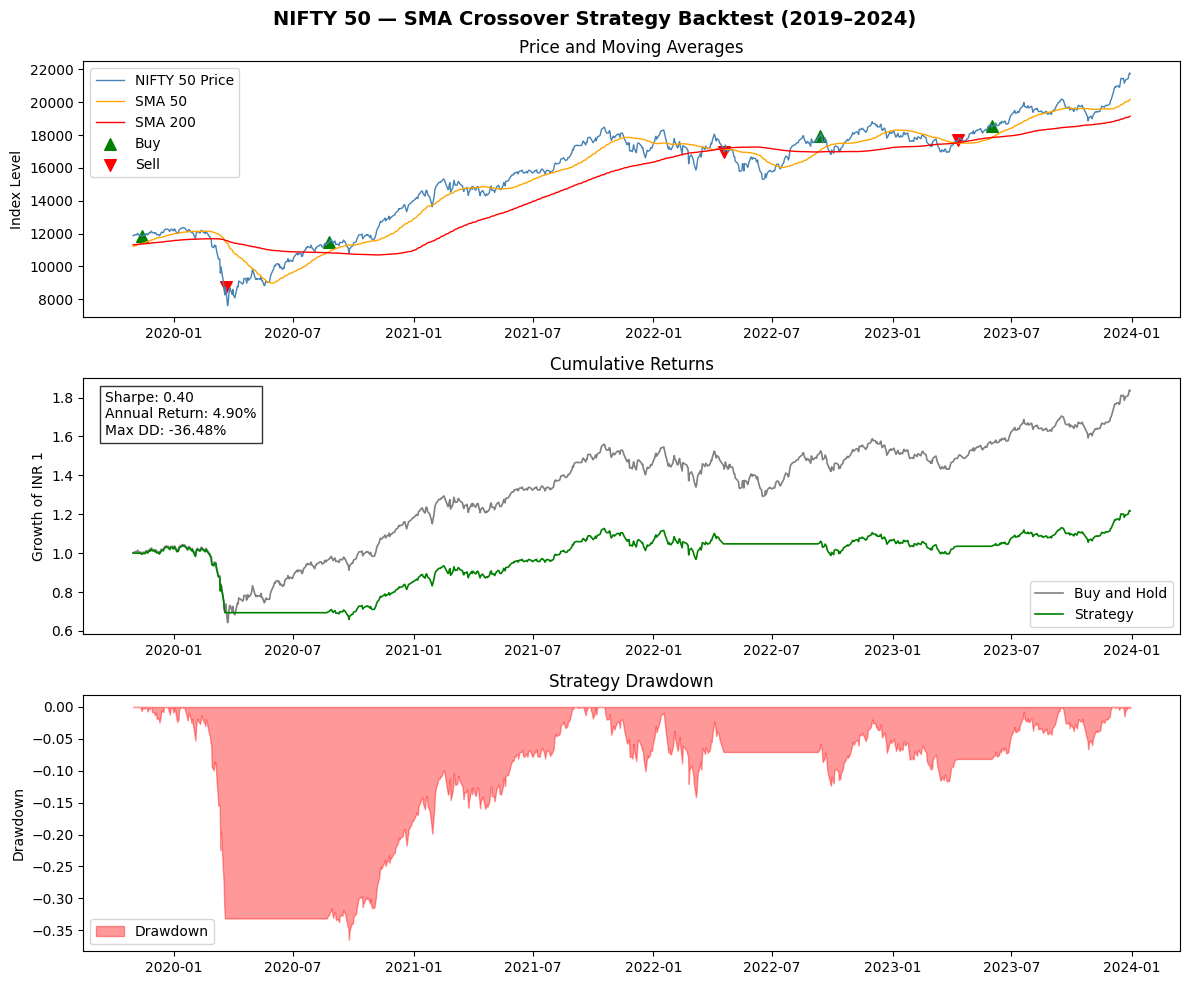

Chart saved.
Results exported.


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle("NIFTY 50 — SMA Crossover Strategy Backtest (2019–2024)",
             fontsize=14, fontweight="bold")

# Plot 1 — Price with SMAs
axes[0].plot(df["Close"],   label="NIFTY 50 Price", linewidth=1, color="steelblue")
axes[0].plot(df["SMA_50"],  label="SMA 50",         linewidth=1, color="orange")
axes[0].plot(df["SMA_200"], label="SMA 200",        linewidth=1, color="red")

axes[0].scatter(
    buy.index,
    buy["Close"],
    marker="^",
    color="green",
    s=70,
    label="Buy"
)

axes[0].scatter(
    sell.index,
    sell["Close"],
    marker="v",
    color="red",
    s=70,
    label="Sell"
)



axes[0].set_title("Price and Moving Averages")
axes[0].legend()
axes[0].set_ylabel("Index Level")

# Plot 2 — Cumulative Returns
axes[1].plot(df["Cumulative_Market"],   label="Buy and Hold", linewidth=1.2, color="gray")
axes[1].plot(df["Cumulative_Strategy"], label="Strategy",     linewidth=1.2, color="green")

metrics = (
    f"Sharpe: {sharpe:.2f}\n"
    f"Annual Return: {annual_return:.2%}\n"
    f"Max DD: {max_drawdown:.2%}"
)

axes[1].text(
    0.02,
    0.95,
    metrics,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)
axes[1].set_title("Cumulative Returns")
axes[1].legend()
axes[1].set_ylabel("Growth of INR 1")

# Plot 3 — Drawdown
axes[2].fill_between(drawdown.index, drawdown, 0, color="red", alpha=0.4, label="Drawdown")
axes[2].set_title("Strategy Drawdown")
axes[2].set_ylabel("Drawdown")
axes[2].legend()

plt.tight_layout()
plt.savefig("nifty_backtest.png", dpi=150)
plt.show()
print("Chart saved.")

df.to_csv("strategy_results.csv")
print("Results exported.")


In [17]:
# Decay analysis — run after your existing code

years = [2019, 2020, 2021, 2022, 2023]

print(f"{'Year':<8} {'Strategy Return':>16} {'Market Return':>14} {'Sharpe':>8}")
print("-" * 50)

for year in years:
    mask = df.index.year == year
    s_ret  = (1 + df.loc[mask, "Strategy_Return"]).prod() - 1
    m_ret  = (1 + df.loc[mask, "Market_Return"]).prod() - 1
    sharpe = (df.loc[mask, "Strategy_Return"].mean() / df.loc[mask, "Strategy_Return"].std()) * np.sqrt(252)
    print(f"{year:<8} {s_ret:>15.2%} {m_ret:>13.2%} {sharpe:>8.2f}")

Year      Strategy Return  Market Return   Sharpe
--------------------------------------------------
2019               2.14%         2.74%     1.63
2020             -16.50%        14.90%    -0.86
2021              24.12%        24.12%     1.48
2022               0.47%         4.33%     0.10
2023              14.42%        20.03%     1.53
